# Iris Detection — YOLO11 + FaceMesh + IrisWrapper

Four-stage pipeline for iris landmark detection on real face images.

| Stage | Model | Output |
|---|---|---|
| Face detection | `YoloFace11Detector` | bounding box + face crop |
| Dense face landmarks | `FaceMeshWrapper` | 478-pt (x, y) in crop space |
| Eye region crop | `crop_eye_regions` | square eye patches, adapts to face size |
| Iris landmarks | `IrisWrapper` | 71 eye pts + 5 iris pts (64×64 model space) |

`crop_eye_regions` accepts coarse 5-pt YOLO11 keypoints **or** dense 478-pt FaceMesh
landmarks.  The square crop size is derived from `scale × inter-eye distance` so it
automatically adapts to any face size.  Here we use the dense path (FaceMesh) for
precise per-eye centroids.

---
The step-by-step walk-through uses `face.jpg` (single frontal face).
The multi-face section at the end uses `multispeaker.png` (3 frontal faces).

/Users/fodorad/miniconda3/envs/exordium/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


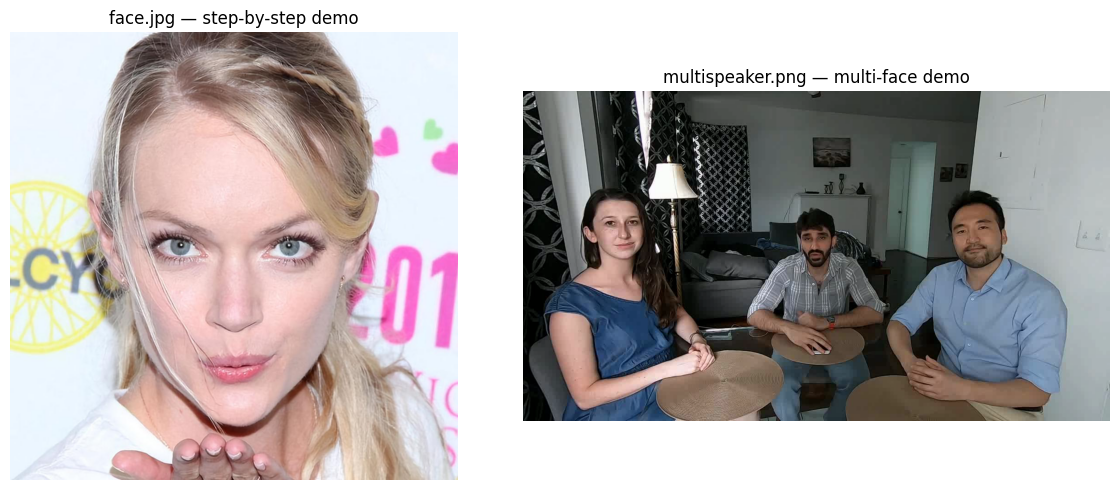

In [1]:
import cv2
import matplotlib.pyplot as plt

from exordium import FIXTURE_DIR
from exordium.video.core.io import image_to_np

face_path = FIXTURE_DIR / "image" / "face.jpg"
multispeaker_path = FIXTURE_DIR / "image" / "multispeaker.png"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_to_np(face_path))
axes[0].set_title("face.jpg — step-by-step demo")
axes[0].axis("off")
axes[1].imshow(image_to_np(multispeaker_path))
axes[1].set_title("multispeaker.png — multi-face demo")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Load models

In [2]:
from exordium.video.face.detector.yolo11 import YoloFace11Detector
from exordium.video.face.landmark import visualize_iris
from exordium.video.face.landmark.constants import FACEMESH_REGION_COLORS
from exordium.video.face.landmark.facemesh import (
    FaceMeshWrapper,
    crop_eye_regions,
    visualize_landmarks,
)
from exordium.video.face.landmark.iris import IrisWrapper

detector = YoloFace11Detector(device_id=None, conf=0.7)
facemesh = FaceMeshWrapper(min_detection_confidence=0.5)
iris_model = IrisWrapper(device_id=None)

2026-03-22 19:27:45 INFO YoloFace11Detector loaded 'yolo11n-pose_widerface' on cpu (conf=0.7).
W0000 00:00:1774204065.279757 2731339 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1774204065.332506 2731339 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1774204065.333499 2731343 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774204065.338522 2731344 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
2026-03-22 19:27:45 INFO MediaPipe FaceMesh loaded.


---
## Step-by-step walk-through — `face.jpg`

### Step 1 — Face detection

YOLO11: 1 face  score=0.851  bb=[260, 204, 756, 905]
face_crop shape: torch.Size([3, 700, 700])


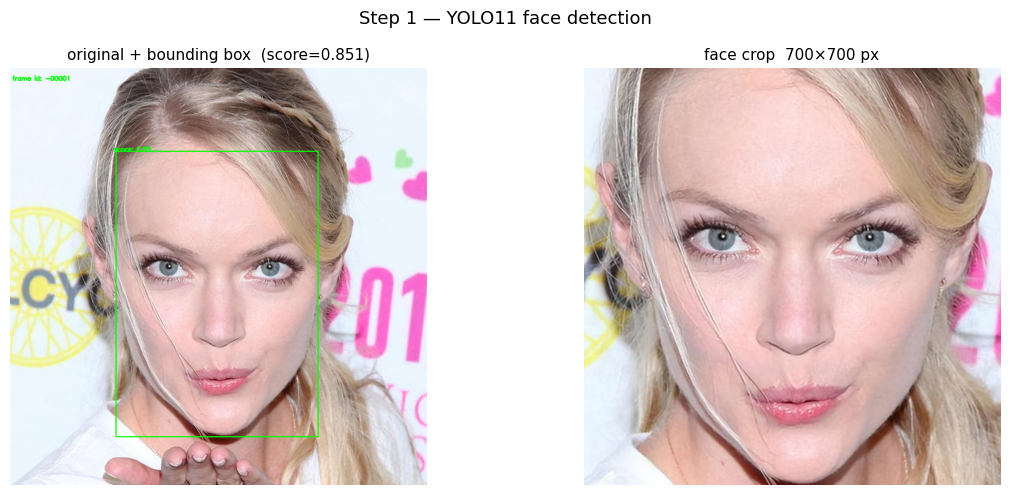

In [9]:
from exordium.video.core.detection import add_detections_to_frame

dets = detector.detect_image_path(face_path)
det = dets[0]
face_crop = det.crop(square=True, extra_space=1.0)  # (3, H', W') uint8 RGB tensor

print(f"YOLO11: {len(dets)} face  score={det.score:.3f}  bb={[int(v) for v in det.bb_xyxy]}")
print(f"face_crop shape: {face_crop.shape}")

# add_detections_to_frame returns BGR — convert to RGB for matplotlib
frame_bgr = add_detections_to_frame(dets, frame=None)
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(frame_rgb)
axes[0].set_title(f"original + bounding box  (score={det.score:.3f})", fontsize=11)
axes[0].axis("off")
axes[1].imshow(face_crop.permute(1, 2, 0).numpy())
axes[1].set_title(f"face crop  {face_crop.shape[1]}×{face_crop.shape[2]} px", fontsize=11)
axes[1].axis("off")
plt.suptitle("Step 1 — YOLO11 face detection", fontsize=13)
plt.tight_layout()
plt.show()

### Step 2 — FaceMesh 478-point landmarks

FaceMesh: 478 landmarks  min=94.3  max=695.2


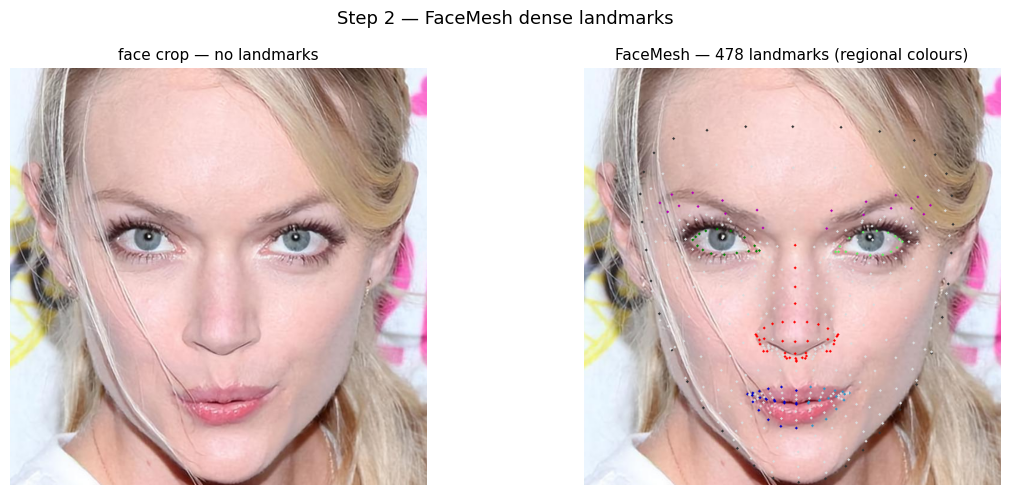

In [11]:
lmks_list = facemesh([face_crop])
lmks = lmks_list[0]  # (478, 2) float32 tensor — pixel coords in face-crop space
print(f"FaceMesh: {lmks.shape[0]} landmarks  min={lmks.min():.1f}  max={lmks.max():.1f}")

vis_mesh = visualize_landmarks(
    face_crop,
    lmks,
    colors=FACEMESH_REGION_COLORS,
    show_indices=False,
    radius=2,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(face_crop.permute(1, 2, 0).numpy())
axes[0].set_title("face crop — no landmarks", fontsize=11)
axes[0].axis("off")
axes[1].imshow(vis_mesh)
axes[1].set_title("FaceMesh — 478 landmarks (regional colours)", fontsize=11)
axes[1].axis("off")
plt.suptitle("Step 2 — FaceMesh dense landmarks", fontsize=13)
plt.tight_layout()
plt.show()

### Step 3 — Eye region crops

`crop_eye_regions` computes the mean centroid of the 16 `RIGHT_EYE` / `LEFT_EYE`
FaceMesh indices per eye, then sets `bb_size = int(inter_eye_distance × scale)`.
The result is a square crop that preserves the original pixel aspect ratio.

right_eye crop: torch.Size([3, 246, 246])  (square=True)
left_eye  crop: torch.Size([3, 246, 246])


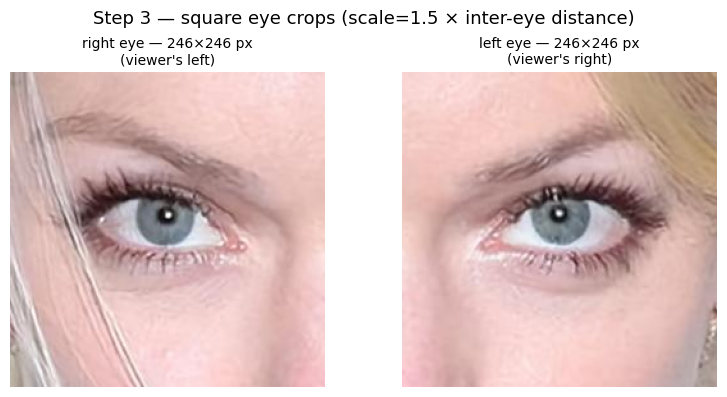

In [12]:
eyes = crop_eye_regions(face_crop, lmks, scale=1.0)
right_eye = eyes["eye_region_right"]  # (3, bb, bb) — subject's right, viewer's left
left_eye = eyes["eye_region_left"]  # (3, bb, bb) — subject's left, viewer's right

print(f"right_eye crop: {right_eye.shape}  (square={right_eye.shape[1] == right_eye.shape[2]})")
print(f"left_eye  crop: {left_eye.shape}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(right_eye.permute(1, 2, 0).numpy())
axes[0].set_title(
    f"right eye — {right_eye.shape[1]}×{right_eye.shape[2]} px\n(viewer's left)", fontsize=10
)
axes[0].axis("off")
axes[1].imshow(left_eye.permute(1, 2, 0).numpy())
axes[1].set_title(
    f"left eye — {left_eye.shape[1]}×{left_eye.shape[2]} px\n(viewer's right)", fontsize=10
)
axes[1].axis("off")
plt.suptitle("Step 3 — square eye crops (scale=1.5 × inter-eye distance)", fontsize=13)
plt.tight_layout()
plt.show()

### Step 4 — Iris detection

`IrisWrapper.eye_to_feature` runs the full pipeline for a single eye crop:
- resizes to 64×64 internally
- predicts **71 eye landmarks** and **5 iris landmarks** in 64×64 model space
- computes **iris diameters**, **eyelid-pupil distances**, and **EAR** — all as torch tensors

right (viewer's left):  iris_diam(h=12.0 v=11.3)  eyelid(top=5.2 bot=6.7)  EAR=0.414
left  (viewer's right):  iris_diam(h=11.0 v=10.5)  eyelid(top=4.0 bot=6.9)  EAR=0.371


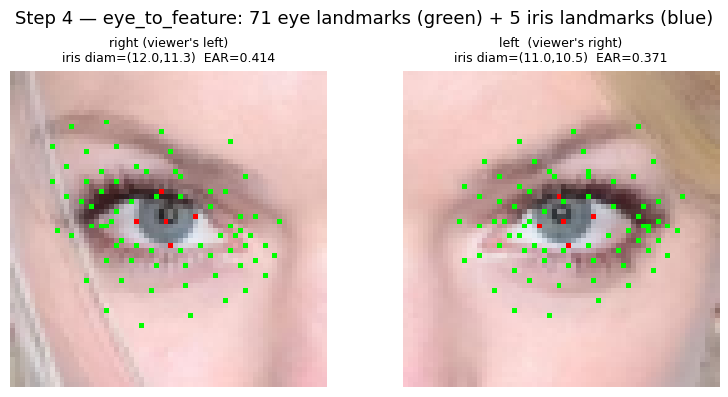

In [13]:
feat_right = iris_model.eye_to_feature(right_eye)
feat_left = iris_model.eye_to_feature(left_eye)
# Each feature dict contains:
#   eye_original  (3, H, W) uint8   — original crop
#   eye           (3, 64, 64) uint8 — 64×64 resized copy
#   eye_region_landmarks  (71, 2)   — eye landmarks in 64×64 space
#   iris_landmarks        (5,  2)   — iris landmarks in 64×64 space
#   iris_diameters        (2,)      — [horizontal, vertical] diameter
#   eyelid_pupil_distances(2,)      — [top, bottom] eyelid-to-pupil distance
#   ear                   scalar    — eye aspect ratio

for feat, side in [
    (feat_right, "right (viewer's left)"),
    (feat_left, "left  (viewer's right)"),
]:
    diam = feat["iris_diameters"]
    dist = feat["eyelid_pupil_distances"]
    ear = feat["ear"]
    print(
        f"{side}:  iris_diam(h={diam[0]:.1f} v={diam[1]:.1f})  "
        f"eyelid(top={dist[0]:.1f} bot={dist[1]:.1f})  EAR={ear:.3f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, feat, side in zip(
    axes,
    [feat_right, feat_left],
    ["right (viewer's left)", "left  (viewer's right)"],
):
    vis = visualize_iris(feat["eye"], feat["eye_region_landmarks"], feat["iris_landmarks"])
    img = vis.permute(1, 2, 0).numpy() if hasattr(vis, "permute") else vis
    diam = feat["iris_diameters"]
    ear = feat["ear"]
    ax.imshow(img)
    ax.set_title(
        f"{side}\niris diam=({diam[0]:.1f},{diam[1]:.1f})  EAR={ear:.3f}",
        fontsize=9,
    )
    ax.axis("off")
plt.suptitle(
    "Step 4 — eye_to_feature: 71 eye landmarks (green) + 5 iris landmarks (blue)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

---
## Multi-face — `multispeaker.png` (3 frontal faces)

In [7]:
dets_ms = detector.detect_image_path(multispeaker_path)
print(f"YOLO11 — {len(dets_ms)} face(s) detected")

face_data = []
for i, det in enumerate(dets_ms):
    fc = det.crop(square=True, extra_space=1.3)
    lm_list = facemesh([fc])
    if not lm_list:
        print(f"  face {i}: FaceMesh found no landmarks — skipped")
        continue
    lm = lm_list[0]
    eyes = crop_eye_regions(fc, lm, scale=1.5)
    re, le = eyes["eye_region_right"], eyes["eye_region_left"]
    feat_r = iris_model.eye_to_feature(re)
    feat_l = iris_model.eye_to_feature(le)
    face_data.append(
        {
            "face_crop": fc,
            "lmks": lm,
            "feat_right": feat_r,
            "feat_left": feat_l,
            "score": det.score,
        }
    )
    print(
        f"  face {i}: score={det.score:.3f}  "
        f"eye={re.shape}  eye_lmks={feat_r['eye_region_landmarks'].shape}"
    )

YOLO11 — 3 face(s) detected
  face 0: score=0.853  eye=torch.Size([3, 68, 68])  eye_lmks=torch.Size([71, 2])
  face 1: score=0.847  eye=torch.Size([3, 68, 68])  eye_lmks=torch.Size([71, 2])
  face 2: score=0.813  eye=torch.Size([3, 42, 42])  eye_lmks=torch.Size([71, 2])


### FaceMesh + iris visualization for all 3 faces

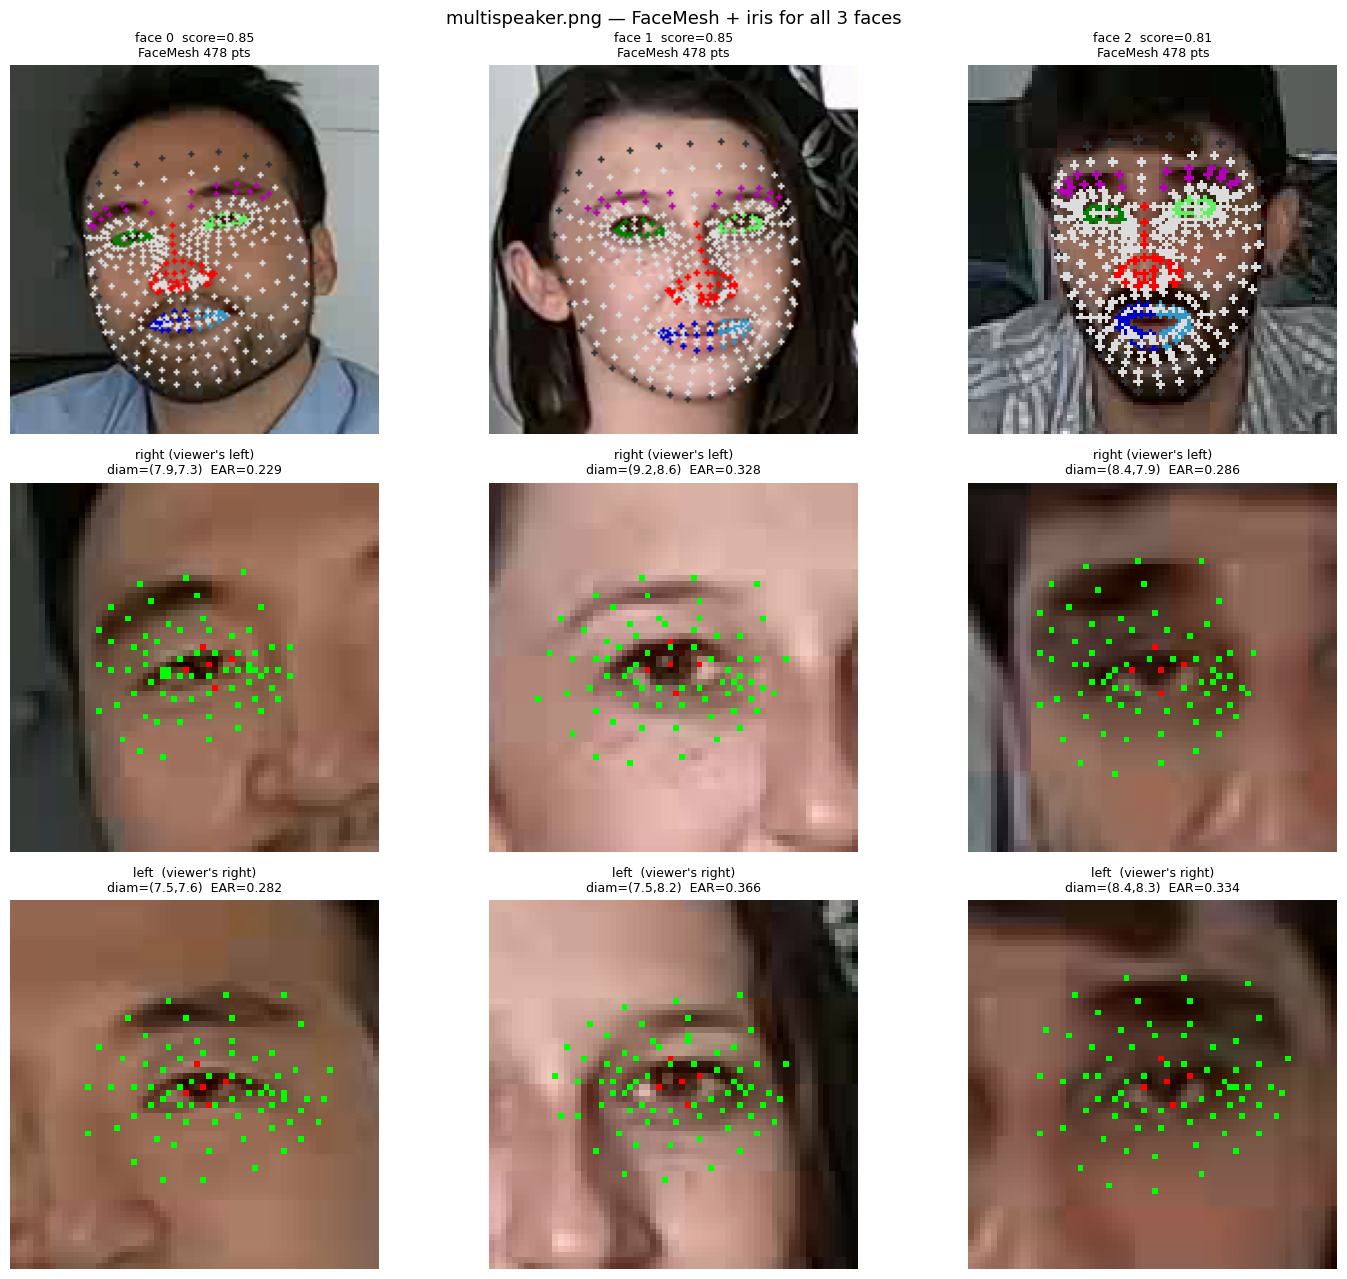

In [8]:
n = len(face_data)
# Row 0: face crops with FaceMesh landmarks
# Row 1: right eye iris   Row 2: left eye iris
fig, axes = plt.subplots(3, n, figsize=(5 * n, 13))

for col, fd in enumerate(face_data):
    # --- row 0: FaceMesh on face crop ---
    vis_fm = visualize_landmarks(
        fd["face_crop"],
        fd["lmks"],
        colors=FACEMESH_REGION_COLORS,
        show_indices=False,
        radius=1,
    )
    axes[0][col].imshow(vis_fm)
    axes[0][col].set_title(f"face {col}  score={fd['score']:.2f}\nFaceMesh 478 pts", fontsize=9)
    axes[0][col].axis("off")

    # --- rows 1 & 2: iris via eye_to_feature ---
    for row, (feat_key, side) in enumerate(
        [
            ("feat_right", "right (viewer's left)"),
            ("feat_left", "left  (viewer's right)"),
        ],
        start=1,
    ):
        feat = fd[feat_key]
        vis = visualize_iris(feat["eye"], feat["eye_region_landmarks"], feat["iris_landmarks"])
        img = vis.permute(1, 2, 0).numpy() if hasattr(vis, "permute") else vis
        diam = feat["iris_diameters"]
        ear = feat["ear"]
        axes[row][col].imshow(img)
        axes[row][col].set_title(
            f"{side}\ndiam=({diam[0]:.1f},{diam[1]:.1f})  EAR={ear:.3f}",
            fontsize=9,
        )
        axes[row][col].axis("off")

plt.suptitle("multispeaker.png — FaceMesh + iris for all 3 faces", fontsize=13)
plt.tight_layout()
plt.show()